<a href="https://colab.research.google.com/github/Samarth041/Deep-Learning/blob/main/transfer_learning_feature_extraction_without_data_augmentation_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("hello")

hello


In [ ]:
!kaggle datasets download -d blourdhuraju/dogs-vs-cats-classification

Dataset URL: https://www.kaggle.com/datasets/blourdhuraju/dogs-vs-cats-classification
License(s): CC0-1.0
100% 775M/775M [00:46<00:00, 17.6MB/s]



In [ ]:
!unzip dogs-vs-cats-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07458.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07459.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07460.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07461.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07462.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07463.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07464.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07465.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07466.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07467.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07468.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07469.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [ ]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,  #top layer(dense layer) is removed
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#adding into new model from scratch

model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
conv_base.trainable = False #base part ko freeze jar diya usko train nahi karenge

In [ ]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/dogs-vs-cats-classification/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/dogs-vs-cats-classification/test',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

Found 19943 files belonging to 2 classes.
Found 2495 files belonging to 2 classes.


In [ ]:
import tensorflow as tf

#Normalise:- we are doing this bcz we want all pixel velues should be b/w 0 and 1 otherwise our result will not be good

def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label

train_ds=train_ds.map(process, num_parallel_calls=tf.data.AUTOTUNE).prefetch(buffer_size=tf.data.AUTOTUNE).ignore_errors()
validation_ds=validation_ds.map(process, num_parallel_calls=tf.data.AUTOTUNE).prefetch(buffer_size=tf.data.AUTOTUNE).ignore_errors()

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
    621/Unknown 74s 104ms/step - accuracy: 0.8543 - loss: 0.3426

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


621/621 ━━━━━━━━━━━━━━━━━━━━ 90s 129ms/step - accuracy: 0.8846 - loss: 0.2683 - val_accuracy: 0.8861 - val_loss: 0.2706
Epoch 2/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.9207 - loss: 0.1915 - val_accuracy: 0.9173 - val_loss: 0.2078
Epoch 3/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 73s 118ms/step - accuracy: 0.9344 - loss: 0.1552 - val_accuracy: 0.9214 - val_loss: 0.2101
Epoch 4/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 74s 119ms/step - accuracy: 0.9450 - loss: 0.1322 - val_accuracy: 0.9111 - val_loss: 0.2432
Epoch 5/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 74s 120ms/step - accuracy: 0.9580 - loss: 0.1050 - val_accuracy: 0.9120 - val_loss: 0.2497
Epoch 6/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 74s 120ms/step - accuracy: 0.9702 - loss: 0.0752 - val_accuracy: 0.8478 - val_loss: 0.5318
Epoch 7/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - accuracy: 0.9752 - loss: 0.0655 - val_accuracy: 0.9046 - val_loss: 0.3060
Epoch 8/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - accuracy: 0.9827 - loss: 0.0456 - val

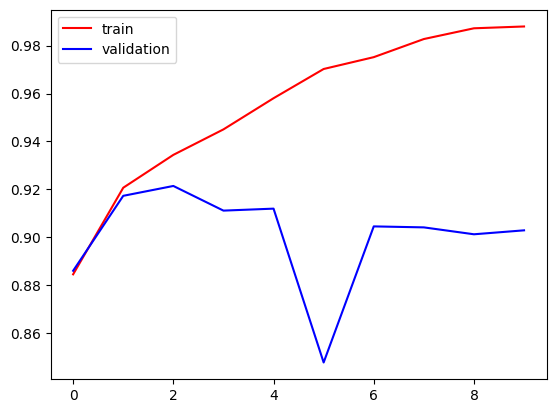

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

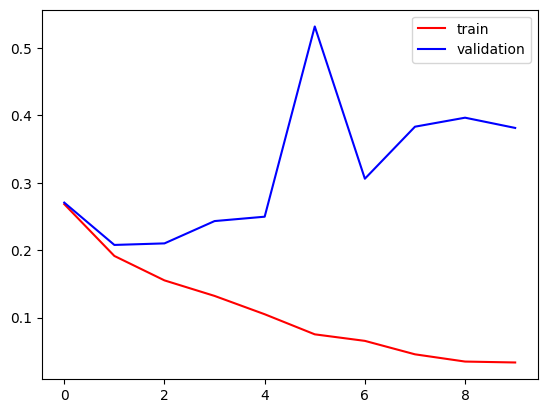

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()